In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib # Useful for saving/loading models

In [2]:
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371 
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return r * c

In [3]:
df = pd.read_csv(r'C:\Users\Asus\Downloads\Dataset_Predict The Fare Amount Of Future Rides Using Regression Analysis\uber.csv')

In [4]:
import warnings
warnings.filterwarnings('ignore') # Keeps the notebook clean from version warnings

In [6]:
# Drop the index column that often appears in CSV exports
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Initial check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


In [7]:
# 1. Drop rows with missing coordinates (usually very few)
df.dropna(inplace=True)

# 2. Convert pickup_datetime to actual datetime objects
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# 3. Basic range filtering (removing negative fares and 0 passengers)
df = df[df['fare_amount'] > 0]
df = df[df['passenger_count'] > 0]

print(f"Dataset loaded successfully with {df.shape[0]} rows.")

Dataset loaded successfully with 199269 rows.


In [8]:
def calculate_distance(lat1, lon1, lat2, lon2):
    # Radius of the Earth in km
    R = 6371.0
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

In [9]:
# Range for New York City area
df = df[((df['pickup_longitude'] > -75) & (df['pickup_longitude'] < -72)) &
        ((df['pickup_latitude'] > 40) & (df['pickup_latitude'] < 42)) &
        ((df['dropoff_longitude'] > -75) & (df['dropoff_longitude'] < -72)) &
        ((df['dropoff_latitude'] > 40) & (df['dropoff_latitude'] < 42))]

print(f"Rows remaining after coordinate filtering: {len(df)}")

Rows remaining after coordinate filtering: 195101


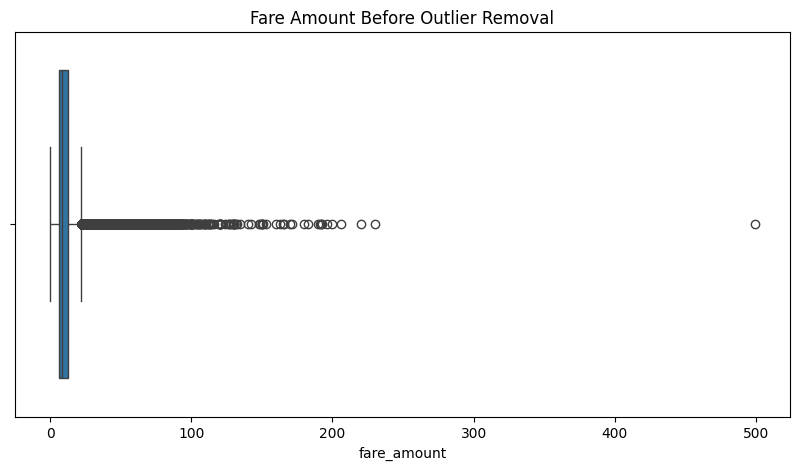

Lower Bound: -3.75
Upper Bound: 22.25
Final row count: 178393


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing before cleaning
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['fare_amount'])
plt.title("Fare Amount Before Outlier Removal")
plt.show()

# Calculating IQR
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

# Defining Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the data
df = df[(df['fare_amount'] >= lower_bound) & (df['fare_amount'] <= upper_bound)]

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Final row count: {len(df)}")

In [11]:
print(df['fare_amount'].describe())

count    178393.000000
mean          8.943250
std           4.138525
min           0.010000
25%           5.700000
50%           8.000000
75%          11.000000
max          22.200000
Name: fare_amount, dtype: float64


In [12]:
# Extracting features from the datetime column
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek

# Now we can drop the original datetime column
df.drop('pickup_datetime', axis=1, inplace=True)

In [13]:
# Applying the Haversine formula
df['dist_travel_km'] = calculate_distance(
    df['pickup_latitude'], 
    df['pickup_longitude'], 
    df['dropoff_latitude'], 
    df['dropoff_longitude']
)

# Display the first few rows of new features
print(df[['fare_amount', 'dist_travel_km', 'hour', 'day_of_week']].head())

   fare_amount  dist_travel_km  hour  day_of_week
0          7.5        1.683323    19            3
1          7.7        2.457590    20            4
2         12.9        5.036377    21            0
3          5.3        1.661683     8            4
4         16.0        4.475450    17            3


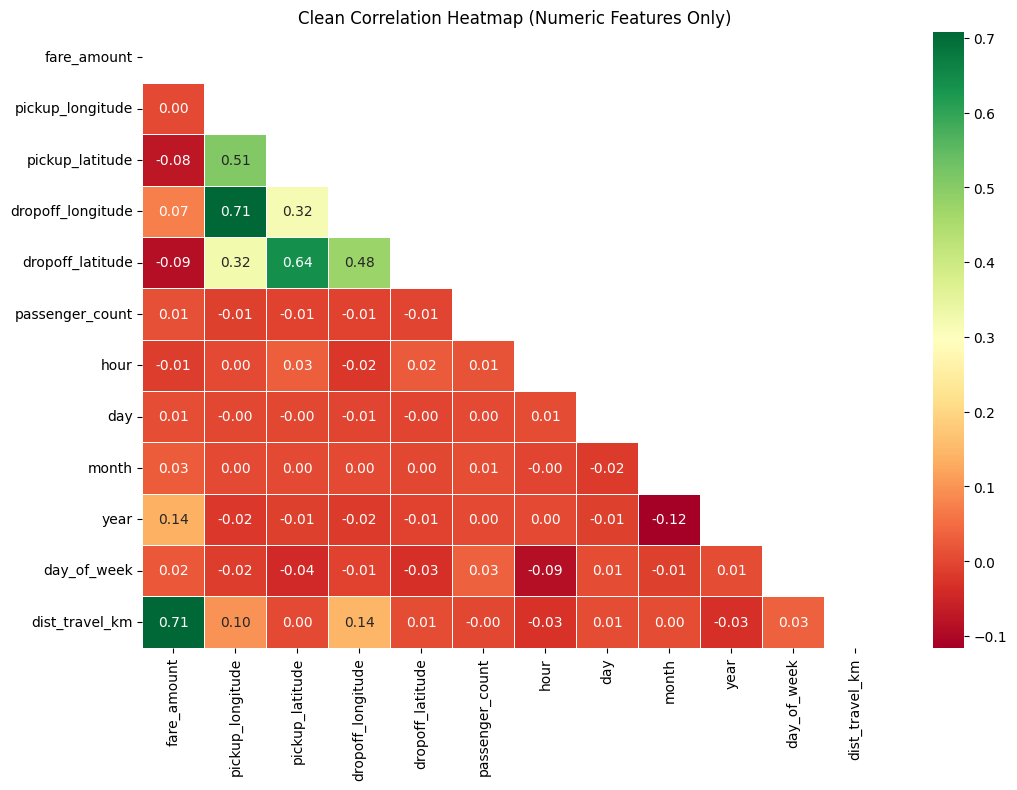

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure we only use numeric columns for correlation
# This automatically ignores any leftover string/object columns
numeric_df = df.select_dtypes(include=[np.number])

# 2. Check if there are any infinite values (inf) which can break the plot
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan).dropna()

# 3. Create the Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = numeric_df.corr()

# Using a 'mask' to hide the upper triangle makes it much easier to read
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            cmap='RdYlGn', 
            fmt=".2f", 
            linewidths=0.5)

plt.title("Clean Correlation Heatmap (Numeric Features Only)")
plt.show()